# Seasonal Agriculture Performance Analysis

## VOIS AICTE Edunet Foundation  Batch1 2026-2027

### Introduction

Agricultural activities are influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market conditions.
Therefore, agricultural performance may vary across different seasons.

This project analyzes the given agricultural dataset to identify seasonal
patterns, trends, relationships and variations in agricultural performance.

The analysis focuses on agricultural yield, profitability, environmental
conditions, resource usage, irrigation practices and other relevant factors.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market conditions.
As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural
performance changes across seasons or what patterns can be observed under
different seasonal conditions.

Therefore, this project aims to analyze the given agricultural dataset and
investigate seasonal differences in agricultural performance by identifying
meaningful patterns, trends, relationships and variations within the available
data.

## Objectives

The main objective of this project is to analyze agricultural data from
different seasons and identify meaningful patterns, trends, relationships
and differences in agricultural performance.

### Specific Objectives

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal conditions and agricultural outcomes.
6. Compare agricultural performance across crops, regions and irrigation methods.
7. Identify significant differences and unusual patterns.
8. Apply appropriate statistical and visualization techniques.
9. Interpret findings based on evidence from the dataset.
10. Develop meaningful conclusions and data-driven recommendations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kruskal

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('/content/agriculture_dataset.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [9]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing = missing[missing['Missing Values'] > 0]

missing

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [12]:
categorical_columns = df.select_dtypes(exclude=np.number).columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

In [13]:
print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


In [14]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,600.92,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.24,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,287.19,3.82,11.96,1.12,0.64,6.68,31.22,17.02,27.74,60.26,1.98,0.10,13.31,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,371.58,23.90,54.77,6.60,6.26,21.80,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,831.98,29.60,71.90,8.10,7.14,31.20,141.22,69.40,123.60,227.20,6.40,0.91,2.83,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [15]:
print(df['Season'].unique())

['Kharif' 'Rabi' 'Zaid']


In [16]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [17]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

season_summary

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,"178,914.65","710,719.06","531,804.41","6,102.20",5.89,54.47
Rabi,5.04,"87,689.47","601,526.05","513,836.58","5,846.99",5.19,40.48
Zaid,4.64,"-24,804.82","519,171.90","543,976.73","6,419.89",4.41,38.22


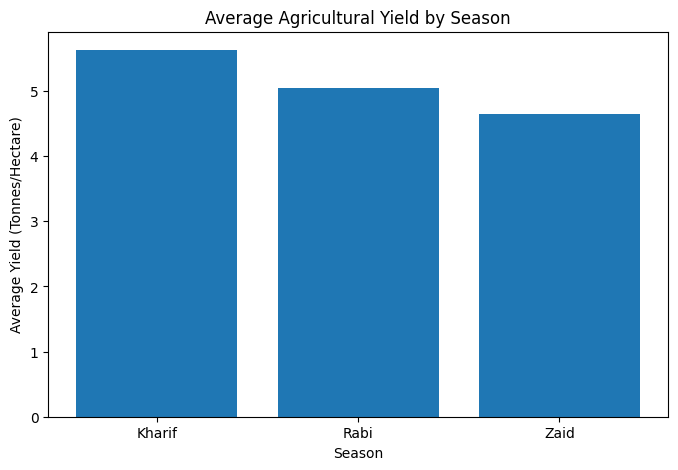

In [18]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(8,5))

plt.bar(season_yield.index, season_yield.values)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')

plt.show()

The chart compares the average agricultural yield across the three seasons.
The season with the highest average yield represents the strongest seasonal
performance in terms of production, while the season with the lowest value
requires further investigation of environmental, resource and farming
conditions.

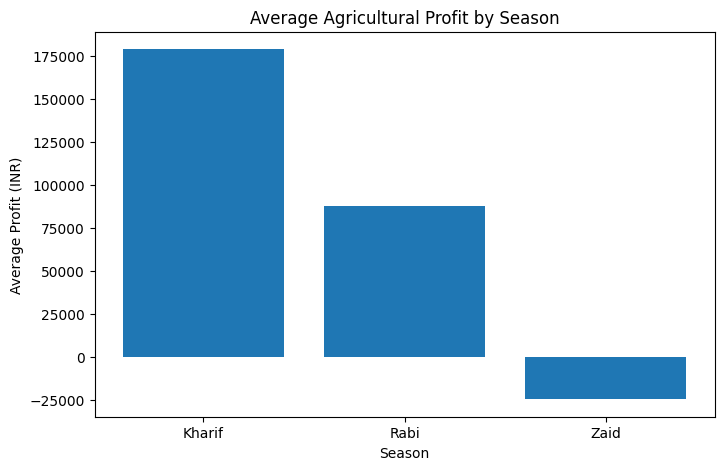

In [19]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

plt.figure(figsize=(8,5))

plt.bar(season_profit.index, season_profit.values)

plt.title('Average Agricultural Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

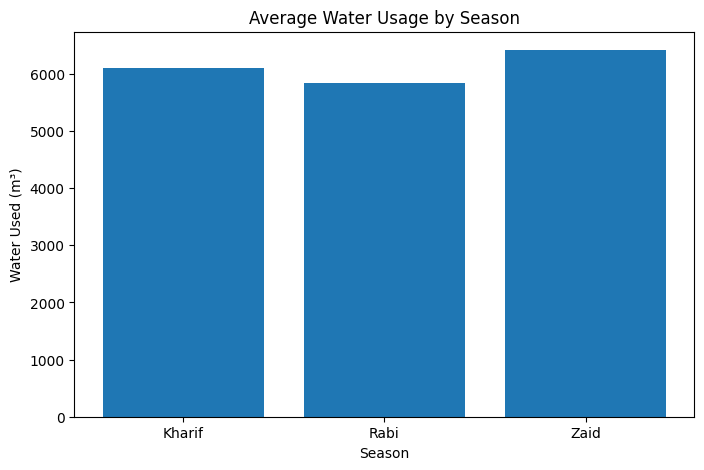

In [20]:
season_water = df.groupby('Season')['Water_Used_m3'].mean()

plt.figure(figsize=(8,5))

plt.bar(season_water.index, season_water.values)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

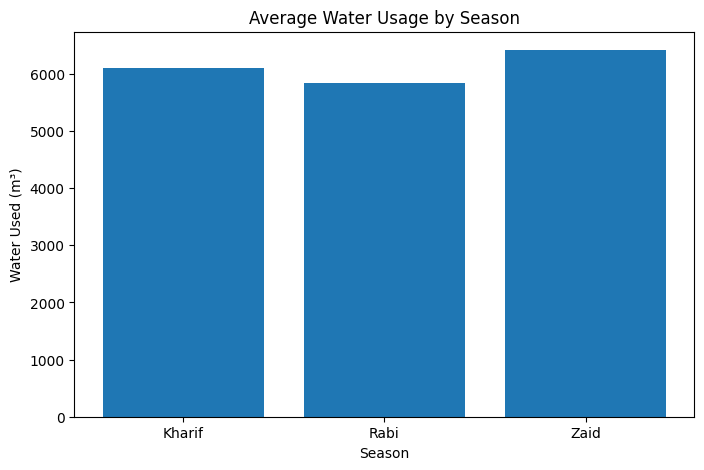

In [21]:
season_water = df.groupby('Season')['Water_Used_m3'].mean()

plt.figure(figsize=(8,5))

plt.bar(season_water.index, season_water.values)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

In [22]:
crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values('Profit_INR', ascending=False)

crop_summary

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Water_Efficiency_t_per_1000m3
Crop,,,,
Sugarcane,46.64,"817,187.99","1,371,980.11",30.48
Chilli,1.54,"750,878.34","1,276,777.23",2.95
Cotton,1.23,"124,546.92","639,423.08",1.94
Groundnut,1.32,"44,858.12","542,935.50",3.15
Pulses,0.92,"-4,238.05","528,465.87",2.90
Maize,2.71,"-83,978.33","457,067.99",5.60
Rice,2.43,"-102,213.50","423,615.26",1.95
Wheat,2.11,"-123,398.34","400,104.89",4.63


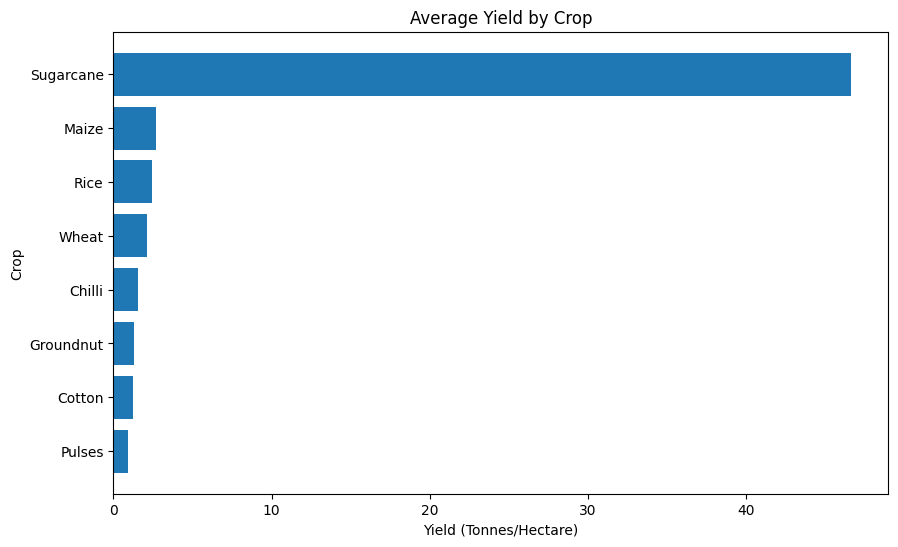

In [23]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values()

plt.figure(figsize=(10,6))

plt.barh(crop_yield.index, crop_yield.values)

plt.title('Average Yield by Crop')
plt.xlabel('Yield (Tonnes/Hectare)')
plt.ylabel('Crop')

plt.show()

In [24]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values('Profit_INR', ascending=False)

state_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
State,,,
Punjab,6.12,"136,025.64",5.62
Maharashtra,5.02,"135,428.86",5.28
Karnataka,5.69,"119,422.34",5.56
Tamil Nadu,4.88,"117,744.75",5.31
Gujarat,5.66,"117,568.24",5.58
Telangana,5.04,"108,829.62",5.46
Madhya Pradesh,4.99,"86,840.76",5.27
Andhra Pradesh,4.63,"73,453.53",5.03


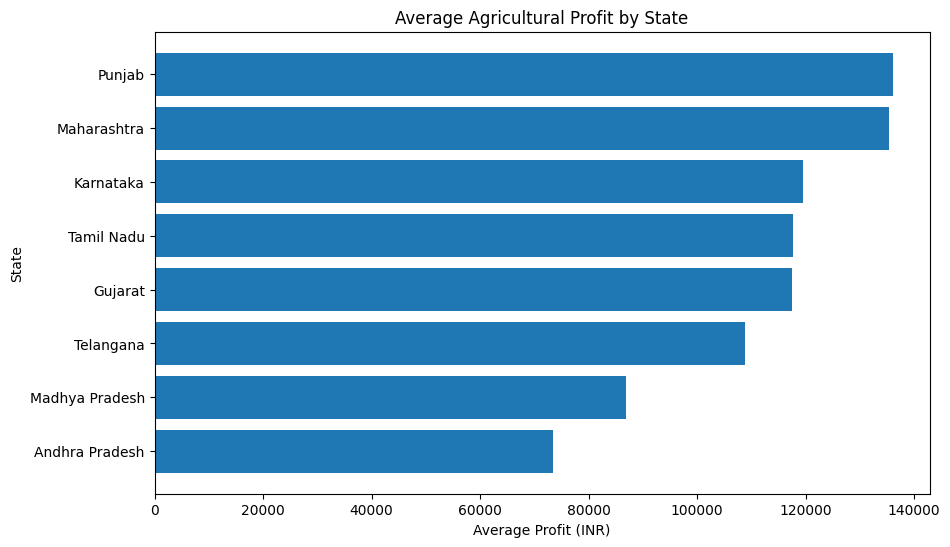

In [25]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values()

plt.figure(figsize=(10,6))

plt.barh(state_profit.index, state_profit.values)

plt.title('Average Agricultural Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')

plt.show()

In [26]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values('Water_Efficiency_t_per_1000m3', ascending=False)

irrigation_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Rainfed,4.60,"79,050.37","3,549.55",7.56
Drip,6.58,"219,626.00","5,918.75",6.27
Sprinkler,5.16,"91,121.08","6,208.26",4.67
Flood,4.86,"73,354.02","8,026.47",3.44


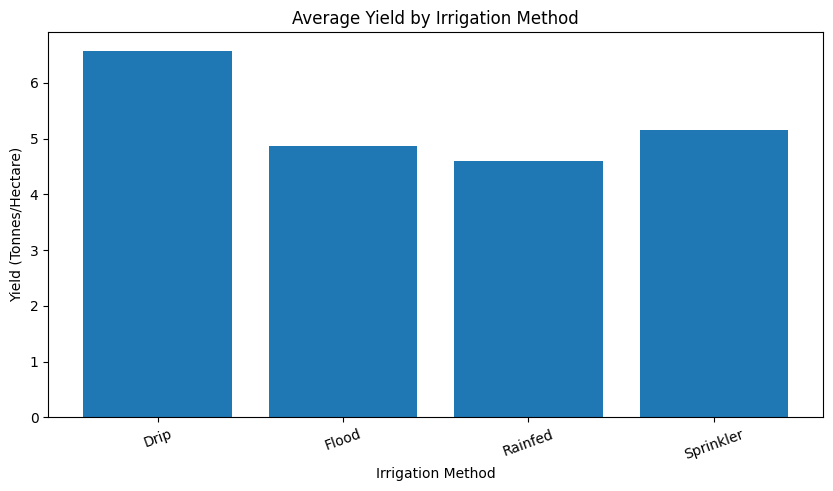

In [27]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(10,5))

plt.bar(irrigation_yield.index, irrigation_yield.values)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.xticks(rotation=20)

plt.show()

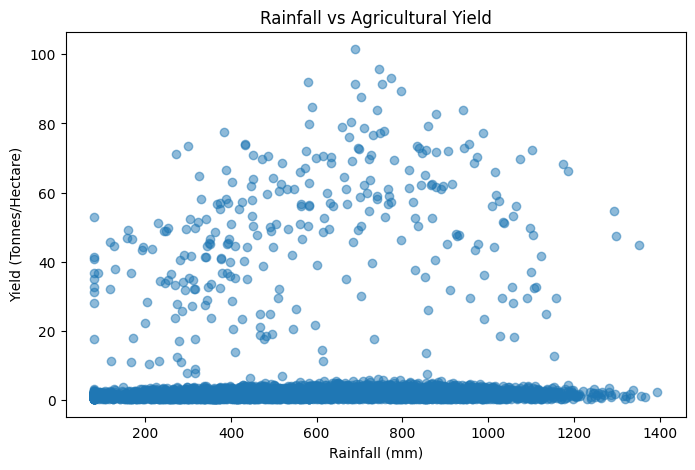

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Hectare)')

plt.show()

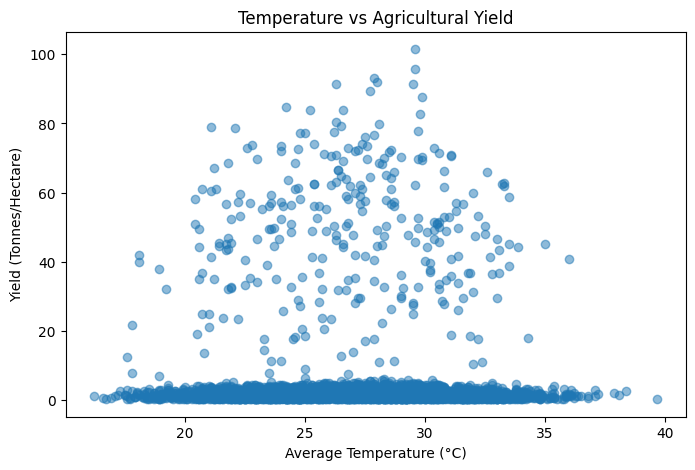

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df['Avg_Temperature_C'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Temperature vs Agricultural Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Hectare)')

plt.show()

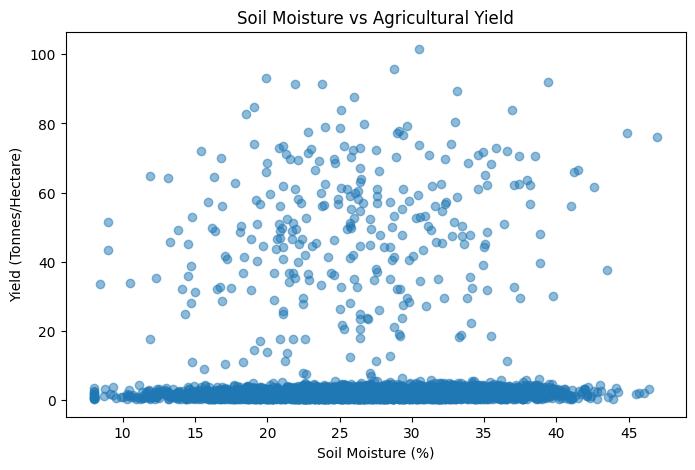

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df['Soil_Moisture_pct'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Soil Moisture vs Agricultural Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Hectare)')

plt.show()

In [33]:
groups = [
    group['Yield_Tonnes_Ha'].values
    for name, group in df.groupby('Season')
]

statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis Statistic:", statistic)
print("p-value:", p_value)

Kruskal-Wallis Statistic: 68.71306722231378
p-value: 1.1999054760748268e-15


In [34]:
if p_value < 0.05:
    print("There is a statistically significant difference in yield among seasons.")
else:
    print("There is not enough statistical evidence of a difference in yield among seasons.")

There is a statistically significant difference in yield among seasons.


In [35]:
best_yield_season = season_summary['Yield_Tonnes_Ha'].idxmax()
best_profit_season = season_summary['Profit_INR'].idxmax()

print("Best season by average yield:", best_yield_season)
print("Best season by average profit:", best_profit_season)

Best season by average yield: Kharif
Best season by average profit: Kharif


In [36]:
best_yield_crop = crop_summary['Yield_Tonnes_Ha'].idxmax()
best_profit_crop = crop_summary['Profit_INR'].idxmax()

print("Highest-yield crop:", best_yield_crop)
print("Highest-profit crop:", best_profit_crop)

Highest-yield crop: Sugarcane
Highest-profit crop: Sugarcane


Based on the analysis performed on the agricultural dataset:

1. Seasonal agricultural performance varies across Kharif, Rabi and Zaid.
2. The season with the highest average yield was identified from the seasonal analysis.
3. The season with the highest average profit was identified from the economic analysis.
4. Crop-level analysis showed differences in yield and profitability.
5. Regional analysis revealed differences among states and districts.
6. Irrigation methods showed differences in yield, water usage and water efficiency.
7. Environmental variables such as rainfall, temperature and soil moisture showed measurable relationships with agricultural yield.
8. Correlation analysis helped identify variables associated with agricultural performance.
9. Statistical testing was used to determine whether seasonal yield differences were statistically significant.